#  Toyota Stock Price Prediction — GRU

**Dataset:** `Toyota_Stock_Prices_1980_2026.csv`  
**Task:** Time Series Forecasting  
**Model:** Gated Recurrent Unit (GRU)

---
###  Daftar Isi
1. Cara Melihat Tipe Data
2. Dataset Bisa Digunakan Untuk Apa
3. Model Yang Bisa Digunakan
4. Parameter Yang Bisa Diubah/Disetel
5. Evaluasi Yang Dipakai
6. Cara Mengetahui Evaluasi Bagus atau Tidak
7. Cara Mengoptimasi Model
8. Cara Menyimpan Model
9. Cara Menggunakan Model Hasil Training

In [1]:
# Install torch jika belum ada
try:
    import torch
    print('PyTorch sudah terinstall, versi:', torch.__version__)
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'torch', '--index-url',
                    'https://download.pytorch.org/whl/cpu', '-q'])
    import torch
    print('PyTorch berhasil diinstall, versi:', torch.__version__)

PyTorch sudah terinstall, versi: 2.10.0+cu128


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib, os, warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from torch.optim.lr_scheduler import ReduceLROnPlateau

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Deteksi device dengan fallback ke CPU jika CUDA tidak benar-benar tersedia
try:
    if torch.cuda.is_available():
        DEVICE = torch.device('cuda')
        torch.zeros(1).to(DEVICE)  # test apakah CUDA benar-benar berfungsi
    else:
        DEVICE = torch.device('cpu')
except Exception:
    DEVICE = torch.device('cpu')

print('Libraries loaded')
print(f'PyTorch version: {torch.__version__}')
print(f'Device: {DEVICE}')

Libraries loaded
PyTorch version: 2.10.0+cu128
Device: cpu


---
## 1.  Cara Melihat Tipe Data

In [3]:
df = pd.read_csv('../Toyota_Stock_Prices_1980_2026.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)
print(df.shape); df.info()
df.head()

(11508, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11508 entries, 0 to 11507
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    11508 non-null  datetime64[ns]
 1   Close   11508 non-null  float64       
 2   High    11508 non-null  float64       
 3   Low     11508 non-null  float64       
 4   Open    11508 non-null  float64       
 5   Volume  11508 non-null  int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 539.6 KB


,Date,Close,High,Low,Open,Volume
0,1980-03-18,1.8207,1.8501,1.8207,1.8207,9343
1,1980-03-19,1.8207,1.8207,1.8207,1.8207,0
2,1980-03-20,1.8207,1.8501,1.8207,1.8207,10277
3,1980-03-21,1.8649,1.8944,1.8649,1.8649,8409
4,1980-03-24,1.8723,1.9017,1.8723,1.8723,2803


---
## 2.  Dataset Bisa Digunakan Untuk Apa

Dataset ini memiliki data OHLCV (Open, High, Low, Close, Volume).

**GRU vs LSTM:**
| Aspek | GRU | LSTM |
|-------|-----|------|
| Gates | 2 (Reset, Update) | 3 (Forget, Input, Output) |
| Kecepatan training | **Lebih cepat** | Lebih lambat |
| Akurasi | Sebanding atau sedikit lebih rendah | Biasanya sedikit lebih tinggi |
| Memori model | **Lebih kecil** | Lebih besar |
| Ketika lebih baik | Data pendek, resource terbatas | Sequence sangat panjang |

**GRU adalah simplifikasi LSTM** yang sering memberikan hasil sebanding dengan training lebih cepat.

In [4]:
df_recent = df[df['Date'] >= '2015-01-01'].copy()
close = df_recent['Close'].values.reshape(-1, 1)

scaler = MinMaxScaler()
close_scaled = scaler.fit_transform(close)

WINDOW = 60

def create_sequences(data, w):
    X, y = [], []
    for i in range(w, len(data)):
        X.append(data[i - w:i, 0])
        y.append(data[i, 0])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

n = len(close_scaled)
split = int(n * 0.8)
train_d = close_scaled[:split]
test_d  = close_scaled[split - WINDOW:]

X_train, y_train = create_sequences(train_d, WINDOW)
X_test,  y_test  = create_sequences(test_d,  WINDOW)
X_train = X_train.reshape(-1, WINDOW, 1)
X_test  = X_test.reshape(-1,  WINDOW, 1)

print(f'X_train: {X_train.shape}, X_test: {X_test.shape}')

# Buat PyTorch Tensors
X_tr_t = torch.tensor(X_train)
y_tr_t = torch.tensor(y_train).unsqueeze(1)
X_te_t = torch.tensor(X_test)
y_te_t = torch.tensor(y_test).unsqueeze(1)

# Validation split
val_split = int(len(X_tr_t) * 0.9)
X_val_t   = X_tr_t[val_split:]
y_val_t   = y_tr_t[val_split:]
X_tr_only = X_tr_t[:val_split]
y_tr_only = y_tr_t[:val_split]

train_ds     = TensorDataset(X_tr_only, y_tr_only)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=False)
print('DataLoader siap')

X_train: (2168, 60, 1), X_test: (558, 60, 1)
DataLoader siap


---
## 3. Arsitektur GRU (PyTorch)

GRU menggunakan dua gate:

$$z_t = \sigma(W_z \cdot [h_{t-1}, x_t])$$  (Update Gate — seberapa banyak info lama dipertahankan)

$$r_t = \sigma(W_r \cdot [h_{t-1}, x_t])$$  (Reset Gate — seberapa banyak info lama dilupakan)

Update terakhir:

$$h_t = (1-z_t) \odot h_{t-1} + z_t \odot \tilde{h}_t$$

Karena lebih sederhana dari LSTM, GRU **lebih cepat** dan cocok ketika data tidak terlalu panjang.

**PyTorch `nn.GRU`** menerima input shape `(batch, seq_len, input_size)` saat `batch_first=True`.

In [5]:
class GRUModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, n_layers=2, dropout=0.2):
        super().__init__()
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=n_layers,
            batch_first=True,
            dropout=dropout if n_layers > 1 else 0.0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        # x: (batch, seq_len, input_size)
        gru_out, _ = self.gru(x)
        # Ambil output dari timestep terakhir saja
        out = self.dropout(gru_out[:, -1, :])
        return self.fc(out)


model = GRUModel(input_size=1, hidden_size=64, n_layers=2, dropout=0.2).to(DEVICE)
print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nTotal trainable parameters: {total_params:,}')

GRUModel(
  (gru): GRU(1, 64, num_layers=2, batch_first=True, dropout=0.2)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=1, bias=True)
  )
)

Total trainable parameters: 39,937


---
## 4. Parameter Yang Bisa Diubah / Disetel

| Parameter | Default | Penjelasan |
|-----------|---------|------------|
| `hidden_size` | 64 | Jumlah neuron GRU per layer |
| `n_layers` | 2 | Kedalaman GRU |
| `dropout` | 0.2 | Regularisasi (aktif jika n_layers > 1) |
| `learning_rate` | 0.001 | Kecepatan belajar Adam |
| `batch_size` | 32 | Mini batch size |
| `WINDOW` | 60 | Sequence length (hari ke belakang) |
| `N_EPOCHS` | 100 | Jumlah epoch maksimum |
| `PATIENCE` | 15 | Early stopping patience |

In [6]:
criterion  = nn.MSELoss()
optimizer  = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler  = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=7, min_lr=1e-6)

N_EPOCHS  = 100
PATIENCE  = 15
best_val_loss = float('inf')
patience_ctr  = 0
best_weights  = None
train_losses, val_losses = [], []

print('Memulai training GRU...')
for epoch in range(1, N_EPOCHS + 1):
    # --- Train ---
    model.train()
    epoch_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        epoch_loss += loss.item() * len(xb)
    epoch_loss /= len(X_tr_only)

    # --- Validation ---
    model.eval()
    with torch.no_grad():
        val_pred = model(X_val_t.to(DEVICE))
        val_loss = criterion(val_pred, y_val_t.to(DEVICE)).item()
    train_losses.append(epoch_loss)
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    # --- Early stopping ---
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_ctr  = 0
        best_weights  = {k: v.clone() for k, v in model.state_dict().items()}
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f'Early stopping at epoch {epoch}')
            break

    if epoch % 10 == 0:
        print(f'Epoch {epoch:3d} | Train Loss: {epoch_loss:.6f} | Val Loss: {val_loss:.6f}')

model.load_state_dict(best_weights)
print('Training selesai!')

Memulai training GRU...
Epoch  10 | Train Loss: 0.011438 | Val Loss: 0.007451
Epoch  20 | Train Loss: 0.001251 | Val Loss: 0.000569
Epoch  30 | Train Loss: 0.000522 | Val Loss: 0.000359
Epoch  40 | Train Loss: 0.000718 | Val Loss: 0.000304
Epoch  50 | Train Loss: 0.000397 | Val Loss: 0.000303
Early stopping at epoch 60
Training selesai!


---
## 5.  Evaluasi Yang Dipakai

In [7]:
model.eval()
with torch.no_grad():
    pred_s = model(X_te_t.to(DEVICE)).cpu().numpy()

pred   = scaler.inverse_transform(pred_s)
actual = scaler.inverse_transform(y_test.reshape(-1, 1))

mae     = mean_absolute_error(actual, pred)
rmse    = np.sqrt(mean_squared_error(actual, pred))
mape    = np.mean(np.abs((actual - pred) / (actual + 1e-8))) * 100
dir_acc = np.mean(
    np.sign(np.diff(actual.flatten())) == np.sign(np.diff(pred.flatten()))
) * 100

print('=' * 50)
print('EVALUASI GRU (PyTorch)')
print('=' * 50)
print(f'MAE            : {mae:.4f}')
print(f'RMSE           : {rmse:.4f}')
print(f'MAPE           : {mape:.2f}%')
print(f'Directional Acc: {dir_acc:.2f}%')

EVALUASI GRU (PyTorch)
MAE            : 3.3809
RMSE           : 4.5971
MAPE           : 1.73%
Directional Acc: 47.76%


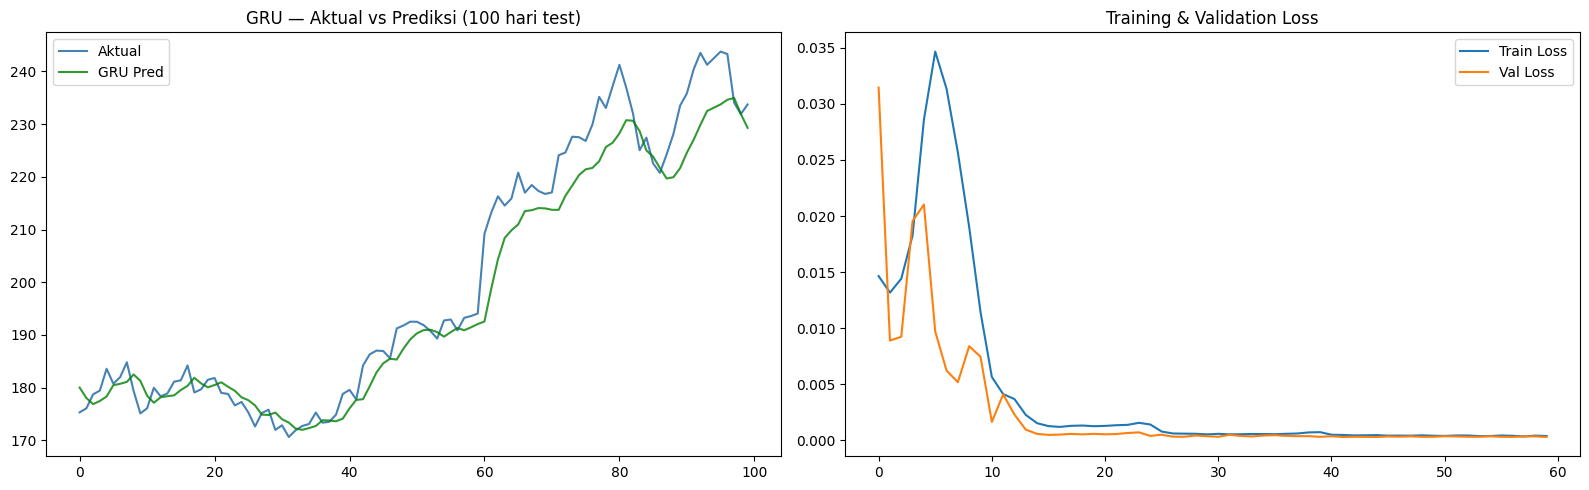

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(actual[:100], label='Aktual', color='steelblue')
axes[0].plot(pred[:100],   label='GRU Pred', color='green', alpha=0.8)
axes[0].set_title('GRU — Aktual vs Prediksi (100 hari test)')
axes[0].legend()

axes[1].plot(train_losses, label='Train Loss')
axes[1].plot(val_losses,   label='Val Loss')
axes[1].set_title('Training & Validation Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 6.  Cara Mengetahui Evaluasi Bagus atau Tidak

### GRU vs LSTM Comparison:

| Aspek | GRU | LSTM |
|-------|-----|------|
| Training time |  Lebih cepat ~20% | Lebih lambat |
| MAPE typical | 2–6% | 2–5% |
| Overfitting risk | Rendah | Rendah |

### Interpretasi:
- Jika **train loss << val loss** → Overfitting → tambah regularisasi
- Jika **val loss masih turun saat epoch berakhir** → Perlu lebih banyak epoch
- Jika **MAPE > 10%** → Model tidak belajar dengan baik, cek preprocessing

---
## 7. Cara Mengoptimasi Model

### Multivariate GRU — tambahkan High, Low, Volume:

```python
features = ['Close', 'High', 'Low', 'Volume']
data_multi = df_recent[features].values
scaler_multi = MinMaxScaler()
data_scaled = scaler_multi.fit_transform(data_multi)

# Shape input: (samples, window, n_features=4)
class MultiGRUModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.gru = nn.GRU(input_size=4, hidden_size=64, num_layers=2,
                          batch_first=True, dropout=0.2)
        self.fc  = nn.Linear(64, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :])
```

### CNN-GRU Hybrid (PyTorch):

```python
class CNNGRUModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2)
        )
        self.gru = nn.GRU(input_size=64, hidden_size=64, batch_first=True)
        self.fc  = nn.Linear(64, 1)

    def forward(self, x):
        # x: (batch, seq_len, 1) -> permute to (batch, 1, seq_len) for Conv1d
        x = x.permute(0, 2, 1)
        x = self.conv(x)
        # permute back to (batch, seq_len_pooled, channels)
        x = x.permute(0, 2, 1)
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :])
```

---
## 8. Cara Menyimpan Model

PyTorch menyimpan dengan `torch.save()`. Simpan **state dict + config** agar bisa membuat ulang model saat loading.

```python
# Simpan
torch.save({'model_state_dict': model.state_dict(), 'config': {...}}, 'path.pth')
# Load
checkpoint = torch.load('path.pth', map_location='cpu')
model.load_state_dict(checkpoint['model_state_dict'])
```

In [9]:
os.makedirs('saved_models', exist_ok=True)

torch.save({
    'model_state_dict': model.state_dict(),
    'config': {
        'input_size': 1,
        'hidden_size': 64,
        'n_layers': 2,
        'dropout': 0.2,
        'window': WINDOW
    },
    'train_losses': train_losses,
    'val_losses':   val_losses
}, 'saved_models/gru_toyota.pth')

joblib.dump(scaler, 'saved_models/scaler_gru.pkl')

print('GRU model tersimpan di saved_models/gru_toyota.pth')
size_kb = os.path.getsize('saved_models/gru_toyota.pth') / 1024
print(f'Ukuran file: {size_kb:.1f} KB')

GRU model tersimpan di saved_models/gru_toyota.pth
Ukuran file: 161.8 KB


---
## 9.  Cara Menggunakan Model Hasil Training

GRU model dimuat (window=60)


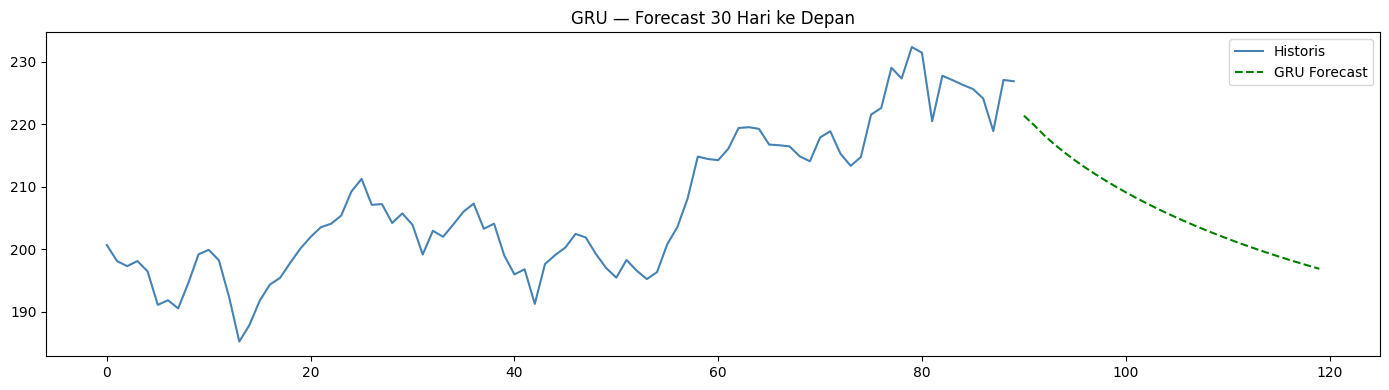

Prediksi besok: $221.36


In [10]:
# Load model
checkpoint    = torch.load('saved_models/gru_toyota.pth', map_location=DEVICE)
cfg           = checkpoint['config']
win           = cfg['window']
loaded_scaler = joblib.load('saved_models/scaler_gru.pkl')

loaded_model = GRUModel(
    input_size=cfg['input_size'],
    hidden_size=cfg['hidden_size'],
    n_layers=cfg['n_layers'],
    dropout=cfg['dropout']
).to(DEVICE)
loaded_model.load_state_dict(checkpoint['model_state_dict'])
loaded_model.eval()
print(f'GRU model dimuat (window={win})')

# Forecast 30 hari ke depan secara iteratif
n_future  = 30
last_seq  = loaded_scaler.transform(close[-win:])
seq       = list(last_seq.flatten())
preds     = []

with torch.no_grad():
    for _ in range(n_future):
        inp = torch.tensor(
            np.array(seq[-win:], dtype=np.float32).reshape(1, win, 1)
        ).to(DEVICE)
        p = loaded_model(inp).item()
        seq.append(p)
        preds.append(p)

preds_real = loaded_scaler.inverse_transform(
    np.array(preds, dtype=np.float32).reshape(-1, 1)
)

# Plot
plt.figure(figsize=(14, 4))
hist = loaded_scaler.inverse_transform(close_scaled[-90:])
plt.plot(hist, label='Historis', color='steelblue')
start = len(hist)
plt.plot(range(start, start + n_future), preds_real,
         label='GRU Forecast', color='green', linestyle='--')
plt.title('GRU — Forecast 30 Hari ke Depan')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Prediksi besok: ${preds_real[0][0]:.2f}')